# Kernel moment-SoS hierarchy vs the standard Lasserre hierarchy

Companion benchmark for Sections 4 and 5 of *Kernel Hierarchies for Global Optimisation*. It compares the kernel relaxation (eq:sdp) (9b), with the Gaussian weight $\omega$ of Example 1 and the partial Taylor datum $\theta_d$, with the standard moment-SoS (Lasserre) relaxation, on four questions:

1. polynomial objectives on a compact semialgebraic $\mathcal X$, where both hierarchies apply: bounds against the order, flatness (10), SDP sizes and solve times;
2. objectives $f=\omega^2q$ with $q$ polynomial: the kernel hierarchy represents $f$ exactly up to the truncation $\theta_d\approx\omega^{-2}$, while the standard hierarchy needs a polynomial approximation of $f$ (Taylor truncation of $e^{-\|x\|^2}$ times $q$, or a Chebyshev fit);
3. conditioning: condition numbers of moment matrices in the monomial, Chebyshev and RKHS-orthonormal coordinates, and solver accuracy as the order grows;
4. scaling of the SDP size and of the solve time in $p$ and $d$.

All SDPs are posed in the scaled variable $u=x/R\in[-1,1]^p$ (box) or $u=x/R$ in the unit ball, which is the change of variables $x=Ru$: in $u$ the weight is $\omega^{-2}=e^{R^2\|u\|^2}$, i.e. **(W)** with $P=R^2I$, and $\theta_d(u)=\sum_{k\le d}R^{2k}\|u\|^{2k}/k!$ is the same polynomial as $\theta_d(x)$. The monomial moment matrices in $x$ and in $u$ differ by the diagonal congruence $\mathrm{diag}(R^{|\alpha|})$.

Solvers: SCS 3.2 (first-order, $\varepsilon_{\rm abs}=\varepsilon_{\rm rel}=10^{-9}$) on every instance, and Clarabel 0.11 (interior point, default settings) when the moment matrix has size $N\le56$. Clarabel works with dense blocks of size $N(N+1)/2$ per PSD cone; in a preliminary run it did not finish a $p=2$, $N=91$ instance within ten minutes, so larger instances are left to SCS. Both are called directly (no cvxpy) so that statuses, iteration counts and residuals are recorded. Fixed seeds; every status is printed.

In [1]:
import itertools, math, time, os, platform
import numpy as np
import scipy
import scipy.sparse as sp
from scipy.optimize import minimize
import clarabel, scs
import mpmath as mp
import matplotlib
import matplotlib.pyplot as plt
from numpy.polynomial import chebyshev as C

T_START = time.perf_counter()
FIGDIR = os.path.join('..', 'figs', 'extra')
os.makedirs(FIGDIR, exist_ok=True)
print('Python', platform.python_version(), '| numpy', np.__version__, '| scipy', scipy.__version__,
      '| clarabel', clarabel.__version__, '| scs', scs.__version__, '| mpmath', mp.__version__,
      '| matplotlib', matplotlib.__version__)
print(platform.platform(), platform.processor())

SCS_EPS = 1e-9        # SCS absolute and relative tolerances
SCS_MAXIT = 50000     # SCS iteration cap
CLAR_NMAX = 56        # Clarabel only for moment matrices of size N <= 56
RANK_TOL = 1e-4       # numerical rank: singular values > RANK_TOL * sigma_1
plt.rcParams.update({'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3, 'legend.fontsize': 7.5,
                     'axes.spines.top': False, 'axes.spines.right': False})

Python 3.13.3 | numpy 2.3.3 | scipy 1.16.1 | clarabel 0.11.1 | scs 3.2.11 | mpmath 1.3.0 | matplotlib 3.10.6
macOS-26.6.2-arm64-arm-64bit-Mach-O arm


## Helpers
Polynomials are dictionaries `{exponent: coefficient}`, either in the monomial basis $u^\alpha$ or in the tensor Chebyshev basis $T_\alpha(u)=\prod_iT_{\alpha_i}(u_i)$, with $T_aT_b=\tfrac12(T_{a+b}+T_{|a-b|})$. A moment vector $y$ is indexed by the basis of degree $\le2n$ and $L_y$ is the Riesz functional.

In [2]:
SQ2 = math.sqrt(2.0)


def exps(p, d):
    """Exponents |a| <= d in graded order."""
    out = []
    for k in range(d + 1):
        for c in itertools.combinations_with_replacement(range(p), k):
            e = [0] * p
            for i in c:
                e[i] += 1
            out.append(tuple(e))
    return out


def _uprod(a, b, basis):
    if basis == 'mono' or a == 0 or b == 0:
        return ((a + b, 1.0),)
    if a == b:
        return ((2 * a, 0.5), (0, 0.5))
    return ((a + b, 0.5), (abs(a - b), 0.5))


_BP = {}


def bprod(e, f, basis):
    """Product of two basis elements, as a dict in the same basis."""
    key = (e, f, basis)
    if key not in _BP:
        terms = {(): 1.0}
        for a, b in zip(e, f):
            new = {}
            for k0, c in terms.items():
                for k, w in _uprod(a, b, basis):
                    new[k0 + (k,)] = new.get(k0 + (k,), 0.0) + c * w
            terms = new
        _BP[key] = terms
    return _BP[key]


def pmul(P, Q, basis='mono'):
    out = {}
    for e, c in P.items():
        for f, w in Q.items():
            for g, v in bprod(e, f, basis).items():
                out[g] = out.get(g, 0.0) + c * w * v
    return out


def deg(P):
    return max(sum(e) for e in P)


_CV = {}


def convert(P, to):
    """Monomial <-> Chebyshev coefficients (to='cheb' or to='mono')."""
    fun = C.poly2cheb if to == 'cheb' else C.cheb2poly

    def uni(k):
        if (to, k) not in _CV:
            v = np.zeros(k + 1)
            v[k] = 1.0
            _CV[(to, k)] = fun(v)
        return _CV[(to, k)]

    out = {}
    for e, c in P.items():
        terms = {(): c}
        for k in e:
            new = {}
            for k0, w in terms.items():
                for j, uj in enumerate(uni(k)):
                    if uj != 0.0:
                        new[k0 + (j,)] = new.get(k0 + (j,), 0.0) + w * uj
            terms = new
        for k0, w in terms.items():
            out[k0] = out.get(k0, 0.0) + w
    return {e: c for e, c in out.items() if c != 0.0}


def in_basis(P, basis):
    return P if basis == 'mono' else convert(P, 'cheb')


def peval(P, U, basis='mono'):
    U = np.atleast_2d(U)
    dmax = deg(P)
    if basis == 'mono':
        pw = [U ** k for k in range(dmax + 1)]
    else:
        A = np.arccos(np.clip(U, -1, 1))
        pw = [np.cos(k * A) for k in range(dmax + 1)]
    out = np.zeros(U.shape[0])
    for e, c in P.items():
        t = np.full(U.shape[0], c)
        for i, k in enumerate(e):
            if k:
                t = t * pw[k][:, i]
        out += t
    return out


def const(p, c=1.0):
    return {(0,) * p: c}


def sqnorm_pow(p, k):
    """||u||^{2k} = sum_{|b|=k} k!/b! u^{2b}."""
    out = {}
    for b in exps(p, k):
        if sum(b) == k:
            out[tuple(2 * x for x in b)] = math.factorial(k) / np.prod([math.factorial(x) for x in b])
    return out


def theta(p, d, R2):
    """theta_d(u) = sum_{k<=d} (R^2||u||^2)^k/k!, partial Taylor sum of omega^{-2} = e^{R^2||u||^2}."""
    out = {}
    for k in range(d + 1):
        for e, c in sqnorm_pow(p, k).items():
            out[e] = out.get(e, 0.0) + c * R2 ** k / math.factorial(k)
    return out


def taylor_w2(p, k, R2):
    """sum_{j<=k} (-R^2||u||^2)^j/j!, Taylor polynomial of omega^2 = e^{-R^2||u||^2}."""
    out = {}
    for j in range(k + 1):
        for e, c in sqnorm_pow(p, j).items():
            out[e] = out.get(e, 0.0) + c * (-R2) ** j / math.factorial(j)
    return out


def box_g(p):
    """1 - u_i^2 >= 0. The ball localizer of p - ||u||^2 is the sum of these, hence implied."""
    return [{(0,) * p: 1.0, tuple(2 if j == i else 0 for j in range(p)): -1.0} for i in range(p)]


def ball_g(p):
    g = {(0,) * p: 1.0}
    for i in range(p):
        g[tuple(2 if j == i else 0 for j in range(p))] = -1.0
    return [g]


def cheb_fit(fun, p, D):
    """Least squares on the (D+1)^p tensor Chebyshev grid by Chebyshev polynomials of total degree <= D."""
    k = np.arange(D + 1)
    nodes = np.cos((2 * k + 1) * np.pi / (2 * (D + 1)))
    G = np.array(list(itertools.product(nodes, repeat=p)))
    E = exps(p, D)
    A = np.arccos(G)
    V = np.ones((G.shape[0], len(E)))
    for c, e in enumerate(E):
        for i, j in enumerate(e):
            if j:
                V[:, c] *= np.cos(j * A[:, i])
    coef = np.linalg.lstsq(V, fun(G), rcond=None)[0]
    return {e: float(c) for e, c in zip(E, coef)}

SDP assembly: $\min L_y(\text{obj})$ s.t. $L_y(\text{norm})=1$, $M_n(y)\succeq0$, $M_{n-1}(g_jy)\succeq0$, in the conic form $Ay+s=b$, $s\in\{0\}\times\mathcal S_+^{N}\times\cdots$ of Clarabel and SCS. With $\text{norm}=\theta_d$ this is (eq:sdp) (9b) (or (12a) when $d<n$); with $\text{norm}=1$ it is the standard relaxation. The dual value is $\lambda=-z_0$, the multiplier of the normalisation. Besides the solver-reported residuals we recompute, on the unscaled problem: the normalisation residual, the most negative eigenvalue of each moment/localising matrix (relative to its largest entry), the dual coefficient residual $\|c+A^\top z\|_\infty$, the most negative eigenvalue of each dual Gram matrix, and the relative gap.

In [3]:
def build(p, n, obj, norm, gs, basis):
    E2 = exps(p, 2 * n)
    idx = {e: i for i, e in enumerate(E2)}
    rows, cols, vals, b = [], [], [], []
    for e, c in norm.items():
        rows.append(0); cols.append(idx[e]); vals.append(c)
    b.append(1.0)
    r = 1
    cones, blocks = [clarabel.ZeroConeT(1)], []
    for g in [const(p) if basis == 'mono' else convert(const(p), 'cheb')] + list(gs):
        B = exps(p, n - math.ceil(deg(g) / 2))
        N = len(B)
        start = r
        for j in range(N):
            for i in range(j + 1):
                s = 1.0 if i == j else SQ2
                for e, c in pmul(g, bprod(B[i], B[j], basis), basis).items():
                    rows.append(r); cols.append(idx[e]); vals.append(-s * c)
                b.append(0.0)
                r += 1
        cones.append(clarabel.PSDTriangleConeT(N))
        blocks.append((start, N))
    A = sp.csc_matrix((vals, (rows, cols)), shape=(r, len(E2)))
    A.eliminate_zeros()
    c = np.zeros(len(E2))
    for e, v in obj.items():
        c[idx[e]] += v
    return dict(p=p, n=n, basis=basis, A=A, b=np.array(b), c=c, cones=cones, blocks=blocks,
                idx=idx, m=len(E2), N=blocks[0][1], rows=r)


def smat(v, N):
    M = np.zeros((N, N))
    k = 0
    for j in range(N):
        for i in range(j + 1):
            M[i, j] = M[j, i] = v[k] if i == j else v[k] / SQ2
            k += 1
    return M


def _negeig(M):
    """Most negative eigenvalue relative to the largest entry (nan if the matrix is not finite)."""
    if not np.all(np.isfinite(M)):
        return np.nan
    try:
        return max(0.0, -np.linalg.eigvalsh(M)[0]) / max(1e-300, np.abs(M).max())
    except np.linalg.LinAlgError:
        return np.nan


def _finish(S, y, z, out):
    s = S['b'] - S['A'] @ y
    Ms = [smat(s[a:a + N * (N + 1) // 2], N) for a, N in S['blocks']]
    Zs = [smat(z[a:a + N * (N + 1) // 2], N) for a, N in S['blocks']]
    pobj = float(S['c'] @ y)
    finite = bool(np.all(np.isfinite(y)) and np.all(np.isfinite(z)))
    if not finite:
        out['ok'] = False
    out.update(pobj=pobj, dobj=-z[0], y=y, M=Ms[0], finite=finite,
               normres=abs((S['A'][0] @ y)[0] - 1.0),
               pcone=max(_negeig(M) for M in Ms),
               dres=np.abs(S['c'] + S['A'].T @ z).max() / max(1.0, np.abs(S['c']).max()),
               dcone=max(_negeig(Z) for Z in Zs),
               gap=abs(pobj + z[0]) / (1.0 + abs(pobj)))
    return out


def solve_clarabel(S):
    st = clarabel.DefaultSettings()
    st.verbose = False
    t0 = time.perf_counter()
    sol = clarabel.DefaultSolver(sp.csc_matrix((S['m'], S['m'])), S['c'], S['A'], S['b'], S['cones'], st).solve()
    out = dict(solver='Clarabel', status=str(sol.status), ok=str(sol.status) == 'Solved', iters=sol.iterations,
               t=time.perf_counter() - t0, r_prim=sol.r_prim, r_dual=sol.r_dual)
    return _finish(S, np.array(sol.x), np.array(sol.z), out)


def _scs_perm(S):
    """Clarabel stores the upper triangle column-wise, SCS the lower triangle column-wise."""
    perm = [0]
    for a, N in S['blocks']:
        pos, k = {}, 0
        for j in range(N):
            for i in range(j + 1):
                pos[(j, i)] = a + k
                k += 1
        perm += [pos[(j, i)] for i in range(N) for j in range(i, N)]
    return np.array(perm)


def solve_scs(S, maxit=None):
    perm = _scs_perm(S)
    data = dict(A=S['A'][perm, :].tocsc(), b=S['b'][perm], c=S['c'])
    cone = dict(z=1, s=[N for _, N in S['blocks']])
    t0 = time.perf_counter()
    sol = scs.SCS(data, cone, eps_abs=SCS_EPS, eps_rel=SCS_EPS, max_iters=maxit or SCS_MAXIT, verbose=False).solve()
    z = np.zeros(len(S['b']))
    z[perm] = sol['y']
    info = sol['info']
    out = dict(solver='SCS', status=info['status'], ok=info['status'] == 'solved', iters=info['iter'],
               t=time.perf_counter() - t0, r_prim=info['res_pri'], r_dual=info['res_dual'])
    return _finish(S, np.array(sol['x']), z, out)


def solve_all(S, maxit=None):
    res = [solve_scs(S, maxit)]
    if S['N'] <= CLAR_NMAX:
        res.append(solve_clarabel(S))
    return res


def best(res):
    """Result used for plots: an 'ok' status first, then the smaller relative gap."""
    def score(r):
        v = r['gap'] + r['dres'] + r['pcone']
        return (not r['ok'], v if np.isfinite(v) else np.inf)
    return sorted(res, key=score)[0]

Flatness (10) with $d_0=1$, numerical rank with relative threshold `RANK_TOL`, and extraction of the atoms from a flat truncation by the multiplication matrices (the linear algebra of Theorem 9). Chebyshev-basis solutions are first converted to monomial moments $L_y(u^\gamma)=\sum_\beta a_{\gamma\beta}L_y(T_\beta)$ (positive, well-conditioned coefficients).

In [4]:
def mono_moments(y, S):
    if S['basis'] == 'mono':
        return y
    ym = np.zeros_like(y)
    for g, i in S['idx'].items():
        ym[i] = sum(c * y[S['idx'][e]] for e, c in convert({g: 1.0}, 'cheb').items())
    return ym


def mmat(ym, S, t, shift=None):
    B = exps(S['p'], t)
    N = len(B)
    M = np.empty((N, N))
    for i in range(N):
        for j in range(i, N):
            e = tuple(a + b for a, b in zip(B[i], B[j]))
            if shift is not None:
                e = tuple(a + b for a, b in zip(e, shift))
            M[i, j] = M[j, i] = ym[S['idx'][e]]
    return M


def nrank(M, tol=RANK_TOL):
    s = np.linalg.svd(M, compute_uv=False)
    return int((s > tol * s[0]).sum())


def flat_info(ym, S):
    ranks = [nrank(mmat(ym, S, t)) for t in range(S['n'] + 1)]
    tf = next((t for t in range(1, S['n'] + 1) if ranks[t] == ranks[t - 1]), None)
    return tf, ranks


def extract(ym, S, t, r):
    p = S['p']
    H0 = mmat(ym, S, t - 1)
    U = np.linalg.svd(H0)[0][:, :r]
    H0r = U.T @ H0 @ U
    Mi = [np.linalg.solve(H0r, U.T @ mmat(ym, S, t - 1, shift=tuple(int(j == i) for j in range(p))) @ U)
          for i in range(p)]
    w = np.random.default_rng(0).random(p)
    _, V = np.linalg.eig(sum(wi * M for wi, M in zip(w / w.sum(), Mi)))
    Vi = np.linalg.inv(V)
    return np.real(np.array([[(Vi @ M @ V)[k, k] for M in Mi] for k in range(r)]))


def atoms_of(r, S):
    """Flat truncation and atoms; falls back to the first-order moments if no flat truncation."""
    ym = mono_moments(r['y'], S)
    if not np.all(np.isfinite(ym)):
        return None, [], np.full((1, S['p']), np.nan)
    tf, ranks = flat_info(ym, S)
    if tf is not None and ranks[tf] <= 8:
        return tf, ranks, extract(ym, S, tf, ranks[tf])
    p = S['p']
    return tf, ranks, np.array([[ym[S['idx'][tuple(int(j == i) for j in range(p))]] / ym[0] for i in range(p)]])

Reference minima (of $f$, of the surrogate $q/\theta_d$ of (12b), and of the polynomial approximants of $f$) by a dense grid (box) or uniform sampling (ball), followed by a local polish from the best candidates.

In [5]:
def global_min(fun, p, domain, ngrid=None, nsamp=200000, npolish=12, seed=0):
    rng = np.random.default_rng(seed)
    if domain == 'box':
        ngrid = ngrid or {1: 400001, 2: 601, 3: 81}[p]
        g = np.linspace(-1, 1, ngrid)
        G = g[:, None] if p == 1 else np.array(list(itertools.product(g, repeat=p)))
        cons, bnds = (), [(-1, 1)] * p
    else:
        G = rng.standard_normal((nsamp, p))
        G *= (rng.random((nsamp, 1)) ** (1 / p)) / np.linalg.norm(G, axis=1)[:, None]
        cons, bnds = ({'type': 'ineq', 'fun': lambda u: 1 - u @ u, 'jac': lambda u: -2 * u},), None
    F = fun(G)
    cand = G[np.argsort(F)[:npolish]]
    best_f, best_x = F.min(), G[F.argmin()]
    for x0 in cand:
        r = minimize(lambda u: fun(u[None])[0], x0, method='SLSQP', bounds=bnds, constraints=cons,
                     options={'ftol': 1e-15, 'maxiter': 500})
        ok = (np.all(np.abs(r.x) <= 1 + 1e-9) if domain == 'box' else r.x @ r.x <= 1 + 1e-9)
        if ok and r.fun < best_f:
            best_f, best_x = r.fun, r.x
    return float(best_f), best_x


def fmt(x):
    return '%.2e' % x

## 1. Polynomial objectives: both hierarchies apply

For a polynomial $f$ the kernel hierarchy with $\omega\equiv1$ (the polynomial kernel of Section 2.2) *is* the standard hierarchy: $\theta_d\equiv1$ and (9b) is Lasserre's SDP. With the Gaussian weight, here $\omega(u)=e^{-\|u\|^2/2}$ in the scaled variable, $f$ must be written as $\omega^2q$ with $q=f\omega^{-2}$, which is not a polynomial. Two ways of doing so, at relaxation order $n$ and with $2m=\deg f$:

* **K-exact**, the order-$n$ relaxation (12a) with truncation order $d=n-m$ and $q=f\,\theta_d$: the surrogate (12b) is $q/\theta_d=f$, so $\rho_{d,n}\le f^\star$ is a lower bound on $f^\star$ itself. At $n=m$, $\theta_0=1$ and K-exact is the standard relaxation.
* **K-native**, the level-$n$ relaxation (9b) with $q=f\,\theta_{n-m}\in\mathbb R_{2n}[X]$: the recipe of Section 5.6 ($\delta_q=\|f-\omega^2q\|_\infty\le\|f\|_\infty\varepsilon_{n-m}$), whose surrogate is $f\,\theta_{n-m}/\theta_n\ne f$.

All three SDPs have the same moment matrix size $N=\binom{p+n}{n}$ and the same localising matrices. Problems: the six-hump camel $f=(4-2.1x_1^2+x_1^4/3)x_1^2+x_1x_2+(4x_2^2-4)x_2^2$ on $[-3,3]\times[-2,2]$ ($f^\star=-1.031628$, two minimisers), and the homogeneous Motzkin form $x_1^4x_2^2+x_1^2x_2^4+x_3^6-3x_1^2x_2^2x_3^2$ on the unit ball of $\mathbb R^3$ ($f^\star=0$, attained on four lines through the origin, so no flat truncation can occur). For the box the ball constraint of Theorem 7 is omitted: its localising matrix is the sum of the box localising matrices, so the relaxation is unchanged.

In [6]:
camel = {(2, 0): 36.0, (4, 0): -2.1 * 81, (6, 0): 729 / 3, (1, 1): 6.0, (0, 2): -16.0, (0, 4): 64.0}  # x1=3u1, x2=2u2
motz = {(4, 2, 0): 1.0, (2, 4, 0): 1.0, (0, 0, 6): 1.0, (2, 2, 2): -3.0}
POLY = {
    'camel': dict(p=2, f=camel, m=3, gs=box_g(2), dom='box', ns=range(3, 8), scale=np.array([3.0, 2.0])),
    'motzkin': dict(p=3, f=motz, m=3, gs=ball_g(3), dom='ball', ns=range(3, 6), scale=np.ones(3)),
}
POLY['camel']['fstar'] = global_min(lambda U: peval(camel, U), 2, 'box')[0]
POLY['motzkin']['fstar'] = 0.0
print('camel f* = %.10f' % POLY['camel']['fstar'])

T1 = time.perf_counter()
rows1 = []
for name, P in POLY.items():
    p, f, m = P['p'], P['f'], P['m']
    for n in P['ns']:
        for meth in ['STD', 'K-exact', 'K-native']:
            if meth == 'STD':
                obj, nrm = f, const(p)
            else:
                th = theta(p, n - m, 1.0)
                obj = pmul(f, th)
                nrm = th if meth == 'K-exact' else theta(p, n, 1.0)
            t0 = time.perf_counter()
            S = build(p, n, obj, nrm, P['gs'], 'mono')
            tb = time.perf_counter() - t0
            res = solve_all(S, maxit=10000)
            r = best(res)
            tf, ranks, at = atoms_of(r, S)
            rows1.append(dict(prob=name, meth=meth, n=n, N=S['N'], nmom=S['m'], rows=S['rows'], tbuild=tb,
                              res=res, bound=r['pobj'], err=r['pobj'] - P['fstar'], tf=tf, ranks=ranks, atoms=at))
            print('%-8s %-9s n=%d N=%3d mom=%4d | ' % (name, meth, n, S['N'], S['m'])
                  + ' | '.join('%s %s it=%d %.4fs bound=%.10f gap=%.1e' % (x['solver'], x['status'], x['iters'], x['t'],
                                                                            x['pobj'], x['gap']) for x in res)
                  + ' | flat t=%s ranks=%s' % (tf, ranks))

camel f* = -1.0316284535
camel    STD       n=3 N= 10 mom=  28 | SCS solved it=350 0.0061s bound=-1.0316284533 gap=5.7e-10 | Clarabel AlmostSolved it=9 0.0024s bound=-1.0316276860 gap=1.6e-07 | flat t=2 ranks=[1, 2, 2, 2]
camel    K-exact   n=3 N= 10 mom=  28 | SCS solved it=350 0.0053s bound=-1.0316284533 gap=5.7e-10 | Clarabel AlmostSolved it=9 0.0018s bound=-1.0316276860 gap=1.6e-07 | flat t=2 ranks=[1, 2, 2, 2]
camel    K-native  n=3 N= 10 mom=  28 | SCS solved it=375 0.0061s bound=-0.9115431231 gap=8.7e-10 | Clarabel AlmostSolved it=8 0.0017s bound=-0.9115455214 gap=1.5e-06 | flat t=2 ranks=[1, 2, 2, 2]
camel    STD       n=4 N= 15 mom=  45 | SCS solved it=325 0.0125s bound=-1.0316284535 gap=4.1e-11 | Clarabel AlmostSolved it=8 0.0092s bound=-1.0316373516 gap=7.1e-07 | flat t=2 ranks=[1, 2, 2, 2, 2]


camel    K-exact   n=4 N= 15 mom=  45 | SCS solved it=375 0.0142s bound=-1.0316284529 gap=2.1e-10 | Clarabel AlmostSolved it=8 0.0094s bound=-1.0316294344 gap=1.9e-06 | flat t=2 ranks=[1, 2, 2, 2, 2]
camel    K-native  n=4 N= 15 mom=  45 | SCS solved it=400 0.0152s bound=-1.0239345879 gap=8.4e-10 | Clarabel AlmostSolved it=8 0.0131s bound=-1.0239682673 gap=7.1e-06 | flat t=2 ranks=[1, 2, 2, 2, 2]
camel    STD       n=5 N= 21 mom=  66 | SCS solved it=350 0.0248s bound=-1.0316284534 gap=3.9e-11 | Clarabel AlmostSolved it=8 0.0272s bound=-1.0316696725 gap=3.3e-06 | flat t=2 ranks=[1, 2, 2, 2, 2, 2]


camel    K-exact   n=5 N= 21 mom=  66 | SCS solved it=425 0.0300s bound=-1.0316284535 gap=7.1e-11 | Clarabel AlmostSolved it=7 0.0270s bound=-1.0318068032 gap=2.3e-05 | flat t=2 ranks=[1, 2, 2, 2, 2, 2]


camel    K-native  n=5 N= 21 mom=  66 | SCS solved it=475 0.0339s bound=-1.0313019938 gap=4.7e-10 | Clarabel AlmostSolved it=7 0.0255s bound=-1.0314647525 gap=2.1e-05 | flat t=2 ranks=[1, 2, 2, 2, 2, 2]
camel    STD       n=6 N= 28 mom=  91 | SCS solved it=350 0.0388s bound=-1.0316284534 gap=7.7e-11 | Clarabel AlmostSolved it=7 0.0782s bound=-1.0317774940 gap=2.0e-05 | flat t=2 ranks=[1, 2, 2, 2, 2, 2, 2]


camel    K-exact   n=6 N= 28 mom=  91 | SCS solved it=425 0.0457s bound=-1.0316284535 gap=3.4e-11 | Clarabel AlmostSolved it=7 0.1081s bound=-1.0317879026 gap=1.2e-05 | flat t=2 ranks=[1, 2, 2, 2, 2, 2, 2]
camel    K-native  n=6 N= 28 mom=  91 | SCS solved it=425 0.0465s bound=-1.0316180784 gap=2.9e-11 | Clarabel AlmostSolved it=7 0.0750s bound=-1.0317800690 gap=1.3e-05 | flat t=2 ranks=[1, 2, 2, 2, 2, 2, 2]


...

motzkin  K-exact   n=4 N= 35 mom= 165 | SCS solved (inaccurate - reached max_iters) it=10000 1.8945s bound=-0.0002258868 gap=9.6e-05 | Clarabel Solved it=14 0.2101s bound=-0.0000911098 gap=1.5e-10 | flat t=None ranks=[1, 4, 10, 18, 25]


motzkin  K-native  n=4 N= 35 mom= 165 | SCS solved (inaccurate - reached max_iters) it=10000 1.8857s bound=-0.0002228171 gap=1.1e-04 | Clarabel Solved it=14 0.1932s bound=-0.0000803108 gap=8.6e-10 | flat t=None ranks=[1, 4, 10, 18, 25]


motzkin  STD       n=5 N= 56 mom= 286 | SCS solved (inaccurate - reached max_iters) it=10000 5.8919s bound=-0.0002007252 gap=5.8e-05 | Clarabel AlmostSolved it=18 1.7622s bound=-0.0000332236 gap=3.0e-08 | flat t=None ranks=[1, 4, 10, 18, 25, 27]


motzkin  K-exact   n=5 N= 56 mom= 286 | SCS solved (inaccurate - reached max_iters) it=10000 5.7286s bound=-0.0001091451 gap=4.3e-05 | Clarabel AlmostSolved it=16 1.6123s bound=-0.0000288841 gap=1.2e-07 | flat t=None ranks=[1, 4, 10, 18, 26, 28]


motzkin  K-native  n=5 N= 56 mom= 286 | SCS solved (inaccurate - reached max_iters) it=10000 5.9888s bound=-0.0001061380 gap=4.3e-05 | Clarabel AlmostSolved it=14 1.3570s bound=-0.0000236568 gap=3.1e-08 | flat t=None ranks=[1, 4, 10, 18, 26, 28]


In [7]:
print('Section 1 solves: %.1f s' % (time.perf_counter() - T1))
print('Extracted atoms (original coordinates), camel:')
for R in rows1:
    if R['prob'] == 'camel':
        print('  %-9s n=%d  t=%s  ' % (R['meth'], R['n'], R['tf']),
              np.round(R['atoms'] * POLY['camel']['scale'], 5).tolist())
print('\nMotzkin on the ball, bounds (f*=0):')
for n in POLY['motzkin']['ns']:
    print('  n=%d  ' % n + '  '.join('%s %.3e' % (R['meth'], R['bound']) for R in rows1
                                    if R['prob'] == 'motzkin' and R['n'] == n))

Section 1 solves: 30.5 s
Extracted atoms (original coordinates), camel:
  STD       n=3  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-exact   n=3  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-native  n=3  t=2   [[-0.08442, 0.6896], [0.08442, -0.6896]]
  STD       n=4  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-exact   n=4  t=2   [[-0.08984, 0.71266], [0.08984, -0.71266]]
  K-native  n=4  t=2   [[0.08922, -0.71009], [-0.08922, 0.71009]]
  STD       n=5  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-exact   n=5  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-native  n=5  t=2   [[-0.0898, 0.71249], [0.0898, -0.71249]]
  STD       n=6  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-exact   n=6  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-native  n=6  t=2   [[0.08984, -0.71265], [-0.08984, 0.71265]]
  STD       n=7  t=2   [[0.08984, -0.71266], [-0.08984, 0.71266]]
  K-exact   n=7  t=2   [[-0.08984, 0.71266], [0.08984, -0.71266]]
  K-nati

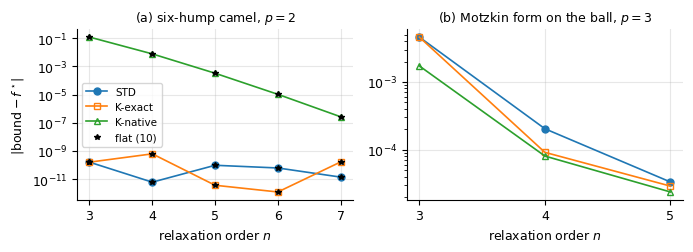

In [8]:
COL = {'STD': 'C0', 'K-exact': 'C1', 'K-native': 'C2', 'KER': 'C1', 'STD-C': 'C0', 'STD-T': 'C2', 'KER-Ctheta': 'C4'}
MRK = {'STD': 'o', 'K-exact': 's', 'K-native': '^', 'KER': 's', 'STD-C': 'o', 'STD-T': '^', 'KER-Ctheta': 'D'}
fig, axs = plt.subplots(1, 2, figsize=(7.0, 2.6))
for ax, name, ttl in zip(axs, POLY, ['(a) six-hump camel, $p=2$', '(b) Motzkin form on the ball, $p=3$']):
    for meth in ['STD', 'K-exact', 'K-native']:
        R = [x for x in rows1 if x['prob'] == name and x['meth'] == meth]
        ns = [x['n'] for x in R]
        err = [max(abs(x['err']), 1e-12) for x in R]
        ax.semilogy(ns, err, marker=MRK[meth], color=COL[meth], lw=1.2, ms=5, label=meth,
                    mfc=COL[meth] if meth == 'STD' else 'none')
        for x in R:
            if x['tf'] is not None:
                ax.plot(x['n'], max(abs(x['err']), 1e-12), marker='*', color='k', ms=4, zorder=5)
    ax.set_xlabel('relaxation order $n$')
    ax.set_title(ttl, fontsize=9)
    ax.set_xticks(list(POLY[name]['ns']))
axs[0].set_ylabel(r'$|\mathrm{bound}-f^\star|$')
axs[0].plot([], [], '*k', ms=4, label='flat (10)')
axs[0].legend(loc='center left')
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'g2_poly.pdf'))
plt.show()

## 2. Non-polynomial objectives $f=\omega^2q$

Problems (original coordinates, $\omega(x)=e^{-\|x\|^2/2}$):

* **Q1**, $p=1$, $\mathcal X=[-2,2]$, $q=x^4-4x^2+x+2$; two local minima;
* **Q2**, $p=2$, $\mathcal X=[-1.5,1.5]^2$, $q=x_1^4+x_2^4-3x_1^2-2x_2^2+x_1x_2+x_1/2+1$; three local minima;
* **Q3**, $p=3$, $\mathcal X$ the unit ball, $q$ a quartic with i.i.d. $\mathcal N(0,1)$ coefficients (seed 0).

Methods at order $n$ (moment matrix size $N=\binom{p+n}{n}$ for all):

* **KER**: the kernel relaxation (9b) at level $d=n$; it bounds the surrogate $f_d^\star=\min q/\theta_d$ and, by Proposition 6, gives a validated lower bound on $f^\star$;
* **STD-T**: the standard relaxation of $f_T=q\sum_{j\le n-m}(-\|x\|^2)^j/j!$, the Taylor truncation of $e^{-\|x\|^2}$ times $q$ (degree $2n$);
* **STD-C**: the standard relaxation of the least-squares Chebyshev fit $f_C$ of $f$ of total degree $2n$ on the bounding box (tensor Chebyshev grid);
* **KER-Cθ** (not in the paper, for diagnosis only): (9b) with $\theta_d$ replaced by the Chebyshev fit of $\omega^{-2}$ of degree $2n$.

For the standard methods the bound is a bound for the approximant; "validated" subtracts $\delta=\max|f-f_{\rm approx}|$ estimated on a fine grid (an estimate, not a rigorous bound). For KER, $\lambda_d<0$ in all runs here, and then Proposition 6 gives $f^\star\ge\lambda_d\max_{\mathcal X}\omega^2\theta_d=\lambda_d$, so the kernel bound is itself validated (up to the SDP accuracy). All SDPs in this section are in the monomial basis; the Chebyshev-basis versions are used in Section 3.

In [9]:
rng0 = np.random.default_rng(0)
E34 = exps(3, 4)
q3 = {e: float(v) for e, v in zip(E34, rng0.standard_normal(len(E34)))}


def scale_poly(qx, R):
    """q(x) -> q(Ru)."""
    return {e: c * R ** sum(e) for e, c in qx.items()}


NONPOLY = {
    'Q1': dict(p=1, R=2.0, dom='box', q=scale_poly({(4,): 1.0, (2,): -4.0, (1,): 1.0, (0,): 2.0}, 2.0),
               ns=list(range(2, 41, 2)), ncheb=list(range(2, 41, 2))),
    'Q2': dict(p=2, R=1.5, dom='box',
               q=scale_poly({(4, 0): 1.0, (0, 4): 1.0, (2, 0): -3.0, (0, 2): -2.0, (1, 1): 1.0, (1, 0): 0.5,
                             (0, 0): 1.0}, 1.5), ns=list(range(2, 15)), ncheb=list(range(2, 13))),
    'Q3': dict(p=3, R=1.0, dom='ball', q=q3, ns=list(range(2, 8)), ncheb=list(range(2, 6))),
}
for name, P in NONPOLY.items():
    p, R2, q = P['p'], P['R'] ** 2, P['q']
    P['gs'] = box_g(p) if P['dom'] == 'box' else ball_g(p)
    P['m'] = math.ceil(deg(q) / 2)
    P['f'] = (lambda q, R2: (lambda U: np.exp(-R2 * np.sum(np.atleast_2d(U) ** 2, 1)) * peval(q, U)))(q, R2)
    P['fstar'], P['xstar'] = global_min(P['f'], p, P['dom'])
    print('%s: f* = %.10f at x* = %s (original coordinates), ||x*||^2 = %.3f' %
          (name, P['fstar'], np.round(P['xstar'] * P['R'], 5), P['R'] ** 2 * P['xstar'] @ P['xstar']))

Q1: f* = -0.7452879288 at x* = [-1.05283] (original coordinates), ||x*||^2 = 1.108
Q2: f* = -0.7368309271 at x* = [-0.86232  0.56365] (original coordinates), ||x*||^2 = 1.061
Q3: f* = -0.9230872448 at x* = [ 0.26135 -0.1782  -0.94865] (original coordinates), ||x*||^2 = 1.000


In [10]:
def ker_bound_validated(lam, P, th):
    """Proposition 6: lam*min(omega^2 theta) if lam >= 0, lam*max(omega^2 theta) = lam if lam < 0."""
    if lam < 0:
        return lam
    rmax2 = P['p'] if P['dom'] == 'box' else 1.0          # max ||u||^2 on X
    t = np.sqrt(rmax2) * np.eye(P['p'])[:1]
    return lam * float(np.exp(-P['R'] ** 2 * rmax2) * peval(th, t)[0])


def dense_pts(P, seed=1):
    if P['dom'] == 'box':
        g = np.linspace(-1, 1, {1: 20001, 2: 401, 3: 61}[P['p']])
        return g[:, None] if P['p'] == 1 else np.array(list(itertools.product(g, repeat=P['p'])))
    G = np.random.default_rng(seed).standard_normal((100000, P['p']))
    return G * (np.random.default_rng(seed + 1).random((100000, 1)) ** (1 / P['p'])) / np.linalg.norm(G, axis=1)[:, None]


T2 = time.perf_counter()
rows2 = []
for name, P in NONPOLY.items():
    p, R2, q, m = P['p'], P['R'] ** 2, P['q'], P['m']
    X = dense_pts(P)
    FX = P['f'](X)
    for n in P['ns']:
        th = theta(p, n, R2)
        fT = pmul(q, taylor_w2(p, n - m, R2))
        fC = cheb_fit(P['f'], p, 2 * n)
        thC = cheb_fit(lambda U: np.exp(R2 * np.sum(U ** 2, 1)), p, 2 * n)
        specs = {
            'KER': (q, th, lambda U: peval(q, U) / peval(th, U), 0.0),
            'STD-T': (fT, const(p), lambda U: peval(fT, U), np.abs(peval(fT, X) - FX).max()),
            'STD-C': (fC, None, lambda U: peval(fC, U, 'cheb'), np.abs(peval(fC, X, 'cheb') - FX).max()),
            'KER-Ctheta': (q, thC, lambda U: peval(q, U) / peval(thC, U, 'cheb'), 0.0),
        }
        for meth, (obj, nrm, sfun, delta) in specs.items():
            if meth == 'KER-Ctheta' and name == 'Q3':
                continue
            bases = ['mono'] + (['cheb'] if meth in ('KER', 'STD-C') and n in P['ncheb'] else [])
            fsur = global_min(sfun, p, P['dom'], ngrid={1: 200001, 2: 401}.get(p), npolish=6)
            for basis in bases:
                if meth in ('STD-C', 'KER-Ctheta'):       # data given in the Chebyshev basis
                    o = fC if meth == 'STD-C' else in_basis(obj, basis)
                    o = convert(o, 'mono') if (meth == 'STD-C' and basis == 'mono') else o
                    nb = convert(const(p), 'cheb') if basis == 'cheb' else const(p)
                    nb = nb if meth == 'STD-C' else (thC if basis == 'cheb' else convert(thC, 'mono'))
                else:
                    o, nb = in_basis(obj, basis), in_basis(nrm, basis)
                gb = [in_basis(g, basis) for g in P['gs']]
                t0 = time.perf_counter()
                S = build(p, n, o, nb, gb, basis)
                tb = time.perf_counter() - t0
                res = solve_all(S) if (basis == 'mono' or p == 1) else [solve_scs(S)]
                r = best(res)
                tf, ranks, at = atoms_of(r, S)
                if meth == 'KER':
                    val = ker_bound_validated(r['dobj'], P, th)
                elif meth == 'KER-Ctheta':          # f >= lam*omega^2*theta on X (grid estimate of the extremum)
                    wt = np.exp(-R2 * np.sum(X ** 2, 1)) * peval(thC, X, 'cheb')
                    val = r['dobj'] * (wt.max() if r['dobj'] < 0 else wt.min())
                else:
                    val = r['dobj'] - delta
                rows2.append(dict(prob=name, meth=meth, basis=basis, n=n, N=S['N'], nmom=S['m'], rows=S['rows'],
                                  nnz=S['A'].nnz, tbuild=tb, res=res, bound=r['pobj'], lam=r['dobj'],
                                  err=r['pobj'] - P['fstar'], val=val, verr=val - P['fstar'], fsur=fsur[0],
                                  xsur=fsur[1], esur=r['pobj'] - fsur[0], delta=delta, tf=tf, ranks=ranks, atoms=at,
                                  M=r['M'], S=S, r=r))
        last = [x for x in rows2 if x['prob'] == name and x['n'] == n and x['basis'] == 'mono']
        print('%s n=%2d N=%3d | ' % (name, n, last[0]['N']) + ' | '.join(
            '%s err=%s val=%s [%s]' % (x['meth'], fmt(x['err']), fmt(x['verr']),
                                       ','.join('%s:%s' % (y['solver'][:3], y['status'][:12]) for y in x['res']))
            for x in last))

Q1 n= 2 N=  3 | KER err=-9.79e-02 val=-9.79e-02 [SCS:solved,Cla:Solved] | STD-T err=-2.70e+00 val=-6.63e+00 [SCS:solved,Cla:Solved] | STD-C err=-3.77e-01 val=-1.31e+00 [SCS:solved,Cla:Solved] | KER-Ctheta err=-6.34e-01 val=-1.11e+00 [SCS:solved,Cla:Solved]
Q1 n= 4 N=  5 | KER err=-4.29e-03 val=-4.29e-03 [SCS:solved,Cla:AlmostSolved] | STD-T err=-6.16e+00 val=-2.61e+01 [SCS:solved,Cla:Solved] | STD-C err=-9.86e-02 val=-2.05e-01 [SCS:solved,Cla:Solved] | KER-Ctheta err=2.46e-02 val=-2.59e-03 [SCS:solved,Cla:AlmostSolved]
Q1 n= 6 N=  7 | KER err=-1.16e-04 val=-1.16e-04 [SCS:solved,Cla:AlmostSolved] | STD-T err=-3.77e+00 val=-2.37e+01 [SCS:solved,Cla:AlmostSolved] | STD-C err=3.24e-03 val=-1.60e-03 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=-5.34e-04 val=-1.31e-03 [SCS:solved,Cla:AlmostSolved]


Q1 n= 8 N=  9 | KER err=-1.92e-06 val=-1.92e-06 [SCS:solved,Cla:AlmostSolved] | STD-T err=-7.29e-01 val=-9.28e+00 [SCS:solved,Cla:AlmostSolved] | STD-C err=-3.11e-08 val=-1.13e-04 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=-3.76e-09 val=-1.04e-05 [SCS:solved,Cla:AlmostSolved]
Q1 n=10 N= 11 | KER err=-2.10e-08 val=-2.11e-08 [SCS:solved,Cla:AlmostSolved] | STD-T err=-1.41e-05 val=-2.05e+00 [SCS:solved,Cla:AlmostSolved] | STD-C err=-8.89e-07 val=-2.45e-06 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=7.06e-08 val=-2.24e-08 [SCS:solved,Cla:AlmostSolved]


Q1 n=12 N= 13 | KER err=-1.63e-10 val=-1.63e-10 [SCS:solved,Cla:AlmostSolved] | STD-T err=-1.61e-07 val=-3.14e-01 [SCS:solved,Cla:AlmostSolved] | STD-C err=9.69e-09 val=-4.59e-09 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=-5.48e-10 val=-1.22e-09 [SCS:solved,Cla:AlmostSolved]


Q1 n=14 N= 15 | KER err=-3.77e-12 val=-4.98e-13 [SCS:solved,Cla:AlmostSolved] | STD-T err=-2.12e-09 val=-3.34e-02 [SCS:solved,Cla:AlmostSolved] | STD-C err=3.93e-12 val=-1.13e-10 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=-1.76e-12 val=-1.83e-12 [SCS:solved,Cla:AlmostSolved]


Q1 n=16 N= 17 | KER err=-5.40e-12 val=-5.52e-14 [SCS:solved,Cla:AlmostSolved] | STD-T err=2.41e-12 val=-2.62e-03 [SCS:solved,Cla:AlmostSolved] | STD-C err=1.08e-11 val=2.17e-11 [SCS:solved,Cla:AlmostSolved] | KER-Ctheta err=-5.41e-12 val=-1.56e-13 [SCS:solved,Cla:AlmostSolved]


...

Q3 n= 3 N= 20 | KER err=-1.79e-02 val=-1.79e-02 [SCS:solved,Cla:AlmostSolved] | STD-T err=3.39e-01 val=-5.71e-01 [SCS:solved,Cla:Solved] | STD-C err=1.89e-02 val=-9.22e-02 [SCS:solved,Cla:AlmostSolved]


Q3 n= 4 N= 35 | KER err=-3.39e-03 val=-3.39e-03 [SCS:solved,Cla:AlmostSolved] | STD-T err=-3.32e-01 val=-6.58e-01 [SCS:solved,Cla:AlmostSolved] | STD-C err=-1.93e-03 val=-2.95e-02 [SCS:solved,Cla:AlmostSolved]


Q3 n= 5 N= 56 | KER err=-5.49e-04 val=-5.49e-04 [SCS:solved,Cla:AlmostSolved] | STD-T err=6.55e-02 val=-1.97e-02 [SCS:solved,Cla:AlmostSolved] | STD-C err=-3.84e-04 val=-5.56e-03 [SCS:solved,Cla:AlmostSolved]


Q3 n= 6 N= 84 | KER err=-7.68e-05 val=-7.68e-05 [SCS:solved] | STD-T err=-1.79e-02 val=-3.54e-02 [SCS:solved] | STD-C err=-1.01e-05 val=-7.87e-04 [SCS:solved]


Q3 n= 7 N=120 | KER err=-9.46e-06 val=-9.46e-06 [SCS:solved] | STD-T err=3.04e-03 val=5.86e-05 [SCS:solved] | STD-C err=1.55e-06 val=-9.58e-05 [SCS:solved]


In [11]:
print('Section 2 solves: %.1f s' % (time.perf_counter() - T2))
print('Status counts, all Section 2 solves:')
cnt = {}
for x in rows2:
    for y in x['res']:
        key = (x['basis'], y['solver'], y['status'])
        cnt[key] = cnt.get(key, 0) + 1
for k, v in sorted(cnt.items()):
    print('  %-5s %-9s %-40s %d' % (k + (v,)))
print('\nFlat truncation (10) found, by method (mono basis):')
for name in NONPOLY:
    for meth in ['KER', 'STD-C', 'STD-T', 'KER-Ctheta']:
        R = [x for x in rows2 if x['prob'] == name and x['meth'] == meth and x['basis'] == 'mono']
        if R:
            print('  %s %-10s ' % (name, meth) + ' '.join('n%d:%s/r%s' % (x['n'], x['tf'], x['ranks'][x['tf']] if x['tf'] else '-')
                                                     for x in R))

Section 2 solves: 162.1 s
Status counts, all Section 2 solves:
  cheb  Clarabel  AlmostSolved                             34
  cheb  Clarabel  Solved                                   6
  cheb  SCS       solved                                   70
  mono  Clarabel  AlmostSolved                             92
  mono  Clarabel  NumericalError                           17
  mono  Clarabel  Solved                                   15
  mono  SCS       solved                                   135
  mono  SCS       solved (inaccurate - reached max_iters)  3
  mono  SCS       unbounded                                5
  mono  SCS       unbounded (inaccurate - reached max_iters) 7

Flat truncation (10) found, by method (mono basis):
  Q1 KER        n2:1/r1 n4:1/r1 n6:1/r1 n8:1/r1 n10:1/r1 n12:1/r1 n14:1/r1 n16:1/r1 n18:1/r1 n20:1/r1 n22:1/r1 n24:1/r1 n26:1/r1 n28:1/r1 n30:1/r1 n32:1/r1 n34:1/r1 n36:1/r1 n38:1/r1 n40:1/r1
  Q1 STD-C      n2:1/r1 n4:1/r1 n6:1/r1 n8:1/r1 n10:1/r1 n12:1/r1 n14:1/r

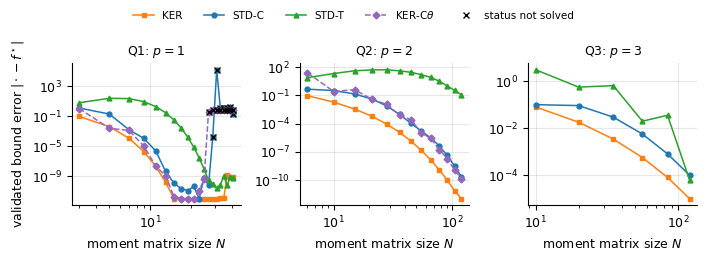

In [12]:
fig, axs = plt.subplots(1, 3, figsize=(7.2, 2.6))
for ax, name in zip(axs, NONPOLY):
    for meth in ['KER', 'STD-C', 'STD-T', 'KER-Ctheta']:
        R = [x for x in rows2 if x['prob'] == name and x['meth'] == meth and x['basis'] == 'mono']
        if not R:
            continue
        N = [x['N'] for x in R]
        ax.loglog(N, [max(abs(x['verr']), 1e-12) for x in R], marker=MRK[meth], color=COL[meth], ms=3.5, lw=1.1,
                  ls='--' if meth == 'KER-Ctheta' else '-', label=meth.replace('Ctheta', r'C$\theta$'))
        bad = [x for x in R if not best(x['res'])['ok']]
        ax.plot([x['N'] for x in bad], [max(abs(x['verr']), 1e-12) for x in bad], 'x', color='k', ms=5)
    P = NONPOLY[name]
    ax.set_title('%s: $p=%d$' % (name, P['p']), fontsize=9)
    ax.set_xlabel('moment matrix size $N$')
axs[0].set_ylabel(r'validated bound error $|\cdot-f^\star|$')
axs[0].plot([], [], 'xk', ms=5, label='status not solved')
h, l = axs[0].get_legend_handles_labels()
fig.legend(h, l, loc='upper center', ncol=5, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.9))
fig.savefig(os.path.join(FIGDIR, 'g2_nonpoly.pdf'))
plt.show()

In [13]:
print('Q2 detail (mono basis): bound error vs f*, validated error, error to own surrogate, delta, time')
for x in rows2:
    if x['prob'] == 'Q2' and x['basis'] == 'mono':
        r = best(x['res'])
        print('  n=%2d N=%3d %-10s err=%9s val=%9s esur=%9s delta=%8s  %s %.2fs' %
              (x['n'], x['N'], x['meth'], fmt(x['err']), fmt(x['verr']), fmt(x['esur']), fmt(x['delta']),
               r['solver'], r['t']))

Q2 detail (mono basis): bound error vs f*, validated error, error to own surrogate, delta, time
  n= 2 N=  6 KER        err=-9.20e-02 val=-9.20e-02 esur=-9.80e-12 delta=0.00e+00  SCS 0.00s
  n= 2 N=  6 STD-T      err=-3.53e+00 val=-7.63e+00 esur= 8.08e-13 delta=4.09e+00  SCS 0.00s
  n= 2 N=  6 STD-C      err= 8.37e-02 val=-4.54e-01 esur= 5.58e-10 delta=5.37e-01  SCS 0.00s
  n= 2 N=  6 KER-Ctheta err=-2.84e+00 val=-2.54e+01 esur= 1.03e-09 delta=0.00e+00  SCS 0.00s
  n= 3 N= 10 KER        err=-1.87e-02 val=-1.87e-02 esur=-3.00e-15 delta=0.00e+00  SCS 0.00s
  n= 3 N= 10 STD-T      err=-9.33e+00 val=-2.10e+01 esur= 1.40e-09 delta=1.17e+01  SCS 0.00s
  n= 3 N= 10 STD-C      err=-3.03e-02 val=-3.24e-01 esur= 4.24e-12 delta=2.94e-01  SCS 0.00s
  n= 3 N= 10 KER-Ctheta err= 5.61e-02 val=-2.54e-01 esur= 1.17e+05 delta=0.00e+00  SCS 0.01s
  n= 4 N= 15 KER        err=-3.56e-03 val=-3.56e-03 esur= 9.54e-13 delta=0.00e+00  SCS 0.01s
  n= 4 N= 15 STD-T      err=-2.01e+01 val=-4.09e+01 esur=-1.87e-11 

## 3. Conditioning

### 3a. Moment matrices of a reference measure
$\mu$ is the uniform probability on $[-1,1]^p$ (in $u$) and $\nu=\omega^2\mu=e^{-R^2\|u\|^2}\mu$ its tilt. For both we compute, in 90-digit arithmetic (mpmath), the condition number of the order-$d$ moment matrix in four coordinate systems: the monomials $u^\alpha$ (the SDP (9b) as written, after scaling); the Chebyshev basis $T_\alpha(u)$; the RKHS-orthonormal Taylor features $\omega(x)x^\alpha/\sqrt{\alpha!}$ of Section 2.2, in which the kernel moment operator (5a) is represented (the matrix $D\,M_d(\nu)\,D$ with $D=\mathrm{diag}(R^{|\alpha|}/\sqrt{\alpha!})$); and the Hermite polynomials orthonormal for $e^{-R^2\|u\|^2}\mathrm du$ on $\mathbb R^p$.

Since $\omega$ takes values in $[e^{-pR^2/2},1]$ on the box (in $u$), the Loewner sandwich $e^{-pR^2}M_d(\mu)\preceq M_d(\nu)\preceq M_d(\mu)$ holds in every basis, so $\kappa(M_d(\nu))/\kappa(M_d(\mu))\in[e^{-pR^2},e^{pR^2}]$ uniformly in $d$.

In [14]:
mp.mp.dps = 90


def umom(kmax, R2, tilt):
    R2 = mp.mpf(R2)
    out = []
    for k in range(kmax + 1):
        if k % 2:
            out.append(mp.mpf(0))
        elif not tilt:
            out.append(mp.mpf(1) / (k + 1))
        else:
            out.append(mp.gammainc(mp.mpf(k + 1) / 2, 0, R2) / (2 * mp.sqrt(R2) ** (k + 1)))
    return out


def rec_coeffs(K, kind, R=1):
    if kind == 'cheb':
        T = [[mp.mpf(1)], [mp.mpf(0), mp.mpf(1)]]
        for j in range(2, K + 1):
            a = [mp.mpf(0)] + [2 * c for c in T[j - 1]]
            T.append([x - y for x, y in zip(a, T[j - 2] + [mp.mpf(0)] * 2)])
        return T[:K + 1]
    R = mp.mpf(R)
    H = [[mp.mpf(1)], [mp.mpf(0), 2 * R]]
    for j in range(2, K + 1):
        a = [mp.mpf(0)] + [2 * R * c for c in H[j - 1]]
        H.append([x - 2 * (j - 1) * y for x, y in zip(a, H[j - 2] + [mp.mpf(0)] * 2)])
    return [[c / mp.sqrt(2 ** j * mp.factorial(j)) for c in H[j]] for j in range(K + 1)]


def mp_momat(p, d, R2, tilt):
    mm = umom(2 * d, R2, tilt)
    B = exps(p, d)
    M = mp.matrix(len(B), len(B))
    for i in range(len(B)):
        for j in range(i, len(B)):
            v = mp.mpf(1)
            for a, b in zip(B[i], B[j]):
                v *= mm[a + b]
            M[i, j] = M[j, i] = v
    return M, B


def mp_change(B, coeffs):
    idx = {e: i for i, e in enumerate(B)}
    T = mp.matrix(len(B), len(B))
    for i, e in enumerate(B):
        terms = {(): mp.mpf(1)}
        for k in e:
            new = {}
            for k0, w in terms.items():
                for j, c in enumerate(coeffs[k]):
                    if c != 0:
                        new[k0 + (j,)] = new.get(k0 + (j,), 0) + w * c
            terms = new
        for k0, w in terms.items():
            T[i, idx[k0]] += w
    return T


def mp_kappa(M):
    E = sorted(mp.eigsy(M, eigvals_only=True))
    return float(E[-1] / E[0])


T3 = time.perf_counter()
COND = []
for p, R, ds in [(1, 1.0, range(2, 31, 2)), (1, 2.0, range(2, 31, 2)), (2, 1.5, range(2, 13, 2))]:
    R2 = R * R
    for d in ds:
        Mm, B = mp_momat(p, d, R2, False)
        Mn, _ = mp_momat(p, d, R2, True)
        Tc = mp_change(B, rec_coeffs(d, 'cheb'))
        Th = mp_change(B, rec_coeffs(d, 'herm', R))
        D = mp.diag([mp.mpf(R) ** sum(e) / mp.sqrt(mp.fprod([mp.factorial(x) for x in e])) for e in B])
        row = dict(p=p, R=R, d=d, N=len(B), mono_mu=mp_kappa(Mm), mono_nu=mp_kappa(Mn),
                   cheb_mu=mp_kappa(Tc * Mm * Tc.T), cheb_nu=mp_kappa(Tc * Mn * Tc.T),
                   rkhs_nu=mp_kappa(D * Mn * D), herm_nu=mp_kappa(Th * Mn * Th.T), bound=math.exp(p * R2))
        COND.append(row)
print('Section 3a (mpmath): %.1f s' % (time.perf_counter() - T3))
print('%2s %4s %3s %4s | %10s %10s %8s | %10s %10s | %10s %10s' % ('p', 'R', 'd', 'N', 'mono mu', 'mono nu', 'ratio',
                                                                  'cheb mu', 'cheb nu', 'RKHS nu', 'Hermite nu'))
for c in COND:
    print('%2d %4.1f %3d %4d | %10.2e %10.2e %8.2f | %10.2e %10.2e | %10.2e %10.2e   e^{pR^2}=%.1f' %
          (c['p'], c['R'], c['d'], c['N'], c['mono_mu'], c['mono_nu'], c['mono_nu'] / c['mono_mu'], c['cheb_mu'],
           c['cheb_nu'], c['rkhs_nu'], c['herm_nu'], c['bound']))

Section 3a (mpmath): 19.1 s
 p    R   d    N |    mono mu    mono nu    ratio |    cheb mu    cheb nu |    RKHS nu Hermite nu
 1  1.0   2    3 |   1.41e+01   1.63e+01     1.16 |   3.79e+00   6.12e+00 |   3.06e+01   9.27e+00   e^{pR^2}=2.7
 1  1.0   4    5 |   3.58e+02   3.87e+02     1.08 |   6.24e+00   1.22e+01 |   5.58e+03   1.04e+03   e^{pR^2}=2.7
 1  1.0   6    7 |   1.02e+04   1.08e+04     1.05 |   8.74e+00   1.83e+01 |   2.63e+06   3.97e+05   e^{pR^2}=2.7
 1  1.0   8    9 |   3.07e+05   3.17e+05     1.03 |   1.13e+01   2.44e+01 |   2.34e+09   3.05e+08   e^{pR^2}=2.7
 1  1.0  10   11 |   9.44e+06   9.66e+06     1.02 |   1.38e+01   3.05e+01 |   3.35e+12   3.91e+11   e^{pR^2}=2.7
 1  1.0  12   13 |   2.96e+08   3.00e+08     1.01 |   1.63e+01   3.66e+01 |   7.05e+15   7.51e+14   e^{pR^2}=2.7
 1  1.0  14   15 |   9.39e+09   9.45e+09     1.01 |   1.89e+01   4.26e+01 |   2.05e+19   2.02e+18   e^{pR^2}=2.7
 1  1.0  16   17 |   3.00e+11   3.01e+11     1.00 |   2.14e+01   4.87e+01 |   7.85e

### 3b. Optimal moment matrices and solver accuracy
At an optimum with a unique minimiser the moment matrix is numerically rank one: for the standard relaxation $M_n(y^\star)\approx v_n(u^\star)v_n(u^\star)^\top$, and for the kernel relaxation $M_n(y^\star)\approx v_n(u^\star)v_n(u^\star)^\top/\theta_n(u^\star)$ (the moments of $\nu^\star=\omega(x^\star)^2\delta_{x^\star}$ normalised by $L_y(\theta_n)=1$), the same matrix up to a scalar. Its condition number $\sigma_1/\sigma_N$ therefore measures the solver's noise floor rather than the problem. We report it with $\sigma_2/\sigma_1$, in the monomial basis (SDP solved in monomials) and in the Chebyshev basis (SDP solved in Chebyshev coordinates), together with the solver status, the recomputed residuals, the error to the SDP's own surrogate optimum (for $p=1$ the relaxation of the surrogate is exact at every order, so this error is purely numerical) and the extraction error.

In [15]:
def sv(M):
    return np.linalg.svd(M, compute_uv=False)


print('%-3s %-6s %-5s %3s %4s | %-9s %-28s %6s | %9s %9s %9s %9s | %9s %9s | %9s %9s' % (
    'P', 'meth', 'basis', 'n', 'N', 'solver', 'status', 'iters', 'normres', 'pcone', 'dres', 'gap',
    'kappa(M)', 's2/s1', 'err_sur', 'err_atom'))
EXTR = []
for x in rows2:
    if x['meth'] not in ('KER', 'STD-C') or x['prob'] == 'Q3' and x['basis'] == 'cheb' and x['n'] > 5:
        continue
    P = NONPOLY[x['prob']]
    for r in x['res']:
        s = sv(r['M']) if r['finite'] else np.full(r['M'].shape[0], np.nan)
        tf, ranks, at = atoms_of(r, x['S'])
        ea = min(np.linalg.norm(a - x['xsur']) for a in at) if len(at) else np.nan
        EXTR.append(dict(prob=x['prob'], meth=x['meth'], basis=x['basis'], n=x['n'], N=x['N'], solver=r['solver'],
                         ok=r['ok'], status=r['status'], kappa=s[0] / s[-1], s21=s[1] / s[0], esur=r['pobj'] - x['fsur'],
                         eatom=ea, spec=s / s[0], t=r['t'], iters=r['iters'], nnz=x['nnz']))
        if x['prob'] in ('Q1', 'Q2') and (x['n'] % 4 == 0 or x['prob'] == 'Q2' and x['n'] % 2 == 0):
            print('%-3s %-6s %-5s %3d %4d | %-9s %-28s %6d | %9.1e %9.1e %9.1e %9.1e | %9.1e %9.1e | %9.1e %9.1e' % (
                x['prob'], x['meth'], x['basis'], x['n'], x['N'], r['solver'], r['status'][:28], r['iters'],
                r['normres'], r['pcone'], r['dres'], r['gap'], s[0] / s[-1], s[1] / s[0], r['pobj'] - x['fsur'], ea))

P   meth   basis   n    N | solver    status                        iters |   normres     pcone      dres       gap |  kappa(M)     s2/s1 |   err_sur  err_atom
Q1  KER    mono    4    5 | SCS       solved                          325 |   4.2e-14   3.0e-11   1.0e-11   2.9e-10 |   1.6e+11   5.5e-11 |   4.7e-10   1.8e-09
Q1  KER    mono    4    5 | Clarabel  AlmostSolved                      9 |   2.8e-09   2.6e-07   5.8e-08   1.5e-07 |   2.8e+07   6.2e-07 |  -6.9e-07   2.5e-05
Q1  KER    cheb    4    5 | SCS       solved                          250 |   2.2e-15   4.8e-14   1.0e-13   4.5e-14 |   2.9e+14   1.7e-14 |   7.9e-14   1.8e-09
Q1  KER    cheb    4    5 | Clarabel  Solved                           10 |   1.2e-09   1.1e-08   1.8e-08   8.8e-10 |   5.2e+08   7.3e-09 |   4.1e-09   1.3e-05
Q1  STD-C  mono    4    5 | SCS       solved                          425 |   5.6e-16   5.5e-13   1.3e-12   2.2e-11 |   8.8e+12   1.6e-12 |   2.8e-11   3.6e-09
Q1  STD-C  mono    4    5 | Clarabel  So

Q2  KER    mono   12   91 | SCS       solved                          250 |   3.3e-16   1.5e-12   6.2e-13   6.5e-14 |   9.3e+17   7.9e-13 |  -8.1e-14   9.4e-09
Q2  KER    cheb   12   91 | SCS       solved                         1050 |   5.5e-13   2.5e-11   3.6e-12   4.9e-13 |   3.2e+16   9.6e-13 |  -3.3e-13   9.4e-09
Q2  STD-C  mono   12   91 | SCS       solved                          525 |   2.9e-15   6.9e-12   5.0e-13   3.6e-11 |   3.2e+16   2.5e-12 |  -4.4e-12   1.2e-08
Q2  STD-C  cheb   12   91 | SCS       solved                         1000 |   9.7e-14   3.0e-12   2.1e-12   1.0e-11 |   2.9e+15   3.5e-13 |   2.3e-12   1.2e-08
Q2  KER    mono   14  120 | SCS       solved                          250 |   2.2e-15   1.9e-12   6.4e-13   1.3e-13 |   1.5e+19   1.0e-12 |  -2.2e-13   1.1e-08
Q2  STD-C  mono   14  120 | SCS       solved                          550 |   1.8e-15   1.7e-11   8.8e-13   5.9e-12 |   1.6e+17   2.3e-11 |  -3.1e-11   6.0e-09


In [16]:
print('Q2, SCS iterations and time, monomial vs Chebyshev basis (same SDP):')
for n in NONPOLY['Q2']['ncheb']:
    line = '  n=%2d ' % n
    for meth in ['KER', 'STD-C']:
        for basis in ['mono', 'cheb']:
            e = [z for z in EXTR if z['prob'] == 'Q2' and z['meth'] == meth and z['basis'] == basis and z['n'] == n
                 and z['solver'] == 'SCS']
            if e:
                line += '| %s/%s it=%5d t=%5.2fs nnz(A)=%6d ' % (meth, basis, e[0]['iters'], e[0]['t'], e[0]['nnz'])
    print(line)

Q2, SCS iterations and time, monomial vs Chebyshev basis (same SDP):
  n= 2 | KER/mono it=  225 t= 0.00s nnz(A)=    51 | KER/cheb it=  225 t= 0.00s nnz(A)=    68 | STD-C/mono it=  150 t= 0.00s nnz(A)=    46 | STD-C/cheb it=  125 t= 0.00s nnz(A)=    63 
  n= 3 | KER/mono it=  250 t= 0.00s nnz(A)=   149 | KER/cheb it=  225 t= 0.00s nnz(A)=   231 | STD-C/mono it=  225 t= 0.00s nnz(A)=   140 | STD-C/cheb it=  125 t= 0.00s nnz(A)=   222 
  n= 4 | KER/mono it=  250 t= 0.01s nnz(A)=   355 | KER/cheb it=  325 t= 0.01s nnz(A)=   642 | STD-C/mono it=  325 t= 0.01s nnz(A)=   341 | STD-C/cheb it=  250 t= 0.01s nnz(A)=   628 
  n= 5 | KER/mono it=  325 t= 0.02s nnz(A)=   732 | KER/cheb it=  225 t= 0.01s nnz(A)=  1519 | STD-C/mono it=  300 t= 0.02s nnz(A)=   712 | STD-C/cheb it=  250 t= 0.02s nnz(A)=  1499 
  n= 6 | KER/mono it=  250 t= 0.02s nnz(A)=  1358 | KER/cheb it=  200 t= 0.02s nnz(A)=  3162 | STD-C/mono it=  400 t= 0.04s nnz(A)=  1331 | STD-C/cheb it=  350 t= 0.04s nnz(A)=  3135 
  n= 7 | KE

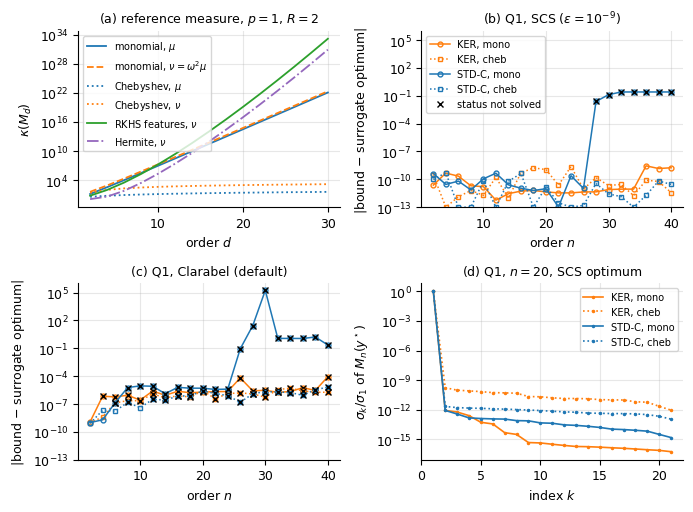

In [17]:
fig, axs = plt.subplots(2, 2, figsize=(7.0, 5.2))
ax = axs[0, 0]
C1 = [c for c in COND if c['p'] == 1 and c['R'] == 2.0]
dd = [c['d'] for c in C1]
for key, lab, col, ls in [('mono_mu', r'monomial, $\mu$', 'C0', '-'), ('mono_nu', r'monomial, $\nu=\omega^2\mu$', 'C1', '--'),
                          ('cheb_mu', r'Chebyshev, $\mu$', 'C0', ':'), ('cheb_nu', r'Chebyshev, $\nu$', 'C1', ':'),
                          ('rkhs_nu', r'RKHS features, $\nu$', 'C2', '-'), ('herm_nu', r'Hermite, $\nu$', 'C4', '-.')]:
    ax.semilogy(dd, [c[key] for c in C1], color=col, ls=ls, lw=1.3, label=lab)
ax.set_xlabel('order $d$')
ax.set_ylabel(r'$\kappa(M_d)$')
ax.set_title(r'(a) reference measure, $p=1$, $R=2$', fontsize=9)
ax.legend(fontsize=7, loc='upper left')
for ax, solver, ttl in [(axs[0, 1], 'SCS', r'(b) Q1, SCS ($\varepsilon=10^{-9}$)'), (axs[1, 0], 'Clarabel', '(c) Q1, Clarabel (default)')]:
    for meth in ['KER', 'STD-C']:
        for basis, ls, mk in [('mono', '-', 'o'), ('cheb', ':', 's')]:
            E = [z for z in EXTR if z['prob'] == 'Q1' and z['meth'] == meth and z['basis'] == basis and z['solver'] == solver]
            if E:
                ax.semilogy([z['n'] for z in E], [max(abs(z['esur']), 1e-13) if np.isfinite(z['esur']) else np.nan for z in E],
                            ls=ls, marker=mk, ms=3.5, color=COL[meth], lw=1.1, mfc='none', label='%s, %s' % (meth, basis))
                bad = [z for z in E if not z['ok']]
                ax.plot([z['n'] for z in bad], [max(abs(z['esur']), 1e-13) for z in bad], 'x', color='k', ms=4)
    ax.set_xlabel('order $n$')
    ax.set_ylabel('|bound $-$ surrogate optimum|')
    ax.set_title(ttl, fontsize=9)
    ax.set_ylim(1e-13, 1e6)
axs[0, 1].plot([], [], 'xk', ms=4, label='status not solved')
axs[0, 1].legend(fontsize=7, loc='upper left')
ax = axs[1, 1]
for meth in ['KER', 'STD-C']:
    for basis, ls in [('mono', '-'), ('cheb', ':')]:
        E = [z for z in EXTR if z['prob'] == 'Q1' and z['meth'] == meth and z['basis'] == basis and z['solver'] == 'SCS'
             and z['n'] == 20]
        if E:
            ax.semilogy(np.arange(1, len(E[0]['spec']) + 1), E[0]['spec'], ls=ls, color=COL[meth], lw=1.2, marker='.',
                        ms=3, label='%s, %s' % (meth, basis))
ax.set_xlabel('index $k$')
ax.set_ylabel(r'$\sigma_k/\sigma_1$ of $M_n(y^\star)$')
ax.set_title('(d) Q1, $n=20$, SCS optimum', fontsize=9)
ax.legend(fontsize=7)
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'g2_cond.pdf'))
plt.show()

## 4. Scaling in $p$ and $d$
Same instance family for all $p$: $\mathcal X$ the unit ball of $\mathbb R^p$, $q$ a quartic with i.i.d. $\mathcal N(0,1)$ coefficients (seed $100+p$), KER at level $d=n$ against STD-T at order $n$ (identical cone structure), monomial basis. Sizes: $N=\binom{p+n}{n}$ (moment matrix), $\binom{p+2n}{2n}$ moments (SDP variables), one localising matrix of size $\binom{p+n-1}{n-1}$. Times are wall-clock of the solver call only (assembly in pure Python is listed separately).

In [18]:
T4 = time.perf_counter()
rows4 = []
for p, nmax in [(1, 20), (2, 12), (3, 7), (4, 5), (5, 4), (6, 3)]:
    rg = np.random.default_rng(100 + p)
    E = exps(p, 4)
    q = {e: float(v) for e, v in zip(E, rg.standard_normal(len(E)))}
    for n in range(2, nmax + 1):
        for meth in ['KER', 'STD-T']:
            obj, nrm = (q, theta(p, n, 1.0)) if meth == 'KER' else (pmul(q, taylor_w2(p, n - 2, 1.0)), const(p))
            t0 = time.perf_counter()
            S = build(p, n, obj, nrm, ball_g(p), 'mono')
            tb = time.perf_counter() - t0
            res = solve_all(S, maxit=20000)
            rows4.append(dict(p=p, n=n, meth=meth, N=S['N'], nmom=S['m'], rows=S['rows'], tbuild=tb, res=res))
    print('p=%d done: ' % p + ', '.join('n=%d N=%d [%s]' % (x['n'], x['N'], ' '.join('%s:%s %.2fs' % (
        y['solver'][:3], y['status'][:8], y['t']) for y in x['res'])) for x in rows4 if x['p'] == p and x['meth'] == 'KER'))

p=1 done: n=2 N=3 [SCS:solved 0.00s Cla:Solved 0.00s], n=3 N=4 [SCS:solved 0.00s Cla:Solved 0.00s], n=4 N=5 [SCS:solved 0.00s Cla:Solved 0.00s], n=5 N=6 [SCS:solved 0.00s Cla:Solved 0.00s], n=6 N=7 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=7 N=8 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=8 N=9 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=9 N=10 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=10 N=11 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=11 N=12 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=12 N=13 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=13 N=14 [SCS:solved 0.00s Cla:AlmostSo 0.01s], n=14 N=15 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=15 N=16 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=16 N=17 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=17 N=18 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=18 N=19 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=19 N=20 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=20 N=21 [SCS:solved 0.01s Cla:AlmostSo 0.02s]


p=2 done: n=2 N=6 [SCS:solved 0.00s Cla:Solved 0.00s], n=3 N=10 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=4 N=15 [SCS:solved 0.00s Cla:AlmostSo 0.01s], n=5 N=21 [SCS:solved 0.01s Cla:AlmostSo 0.02s], n=6 N=28 [SCS:solved 0.01s Cla:AlmostSo 0.05s], n=7 N=36 [SCS:solved 0.03s Cla:AlmostSo 0.15s], n=8 N=45 [SCS:solved 0.05s Cla:AlmostSo 0.34s], n=9 N=55 [SCS:solved 0.08s Cla:AlmostSo 0.90s], n=10 N=66 [SCS:solved 0.12s], n=11 N=78 [SCS:solved 0.17s], n=12 N=91 [SCS:solved 0.24s]


p=3 done: n=2 N=10 [SCS:solved 0.00s Cla:Solved 0.00s], n=3 N=20 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=4 N=35 [SCS:solved 0.02s Cla:AlmostSo 0.09s], n=5 N=56 [SCS:solved 0.06s Cla:AlmostSo 0.57s], n=6 N=84 [SCS:solved 0.16s], n=7 N=120 [SCS:solved 0.34s]


p=4 done: n=2 N=15 [SCS:solved 0.00s Cla:AlmostSo 0.00s], n=3 N=35 [SCS:solved 0.02s Cla:AlmostSo 0.08s], n=4 N=70 [SCS:solved 0.10s], n=5 N=126 [SCS:solved 0.33s]


p=5 done: n=2 N=21 [SCS:solved 0.01s Cla:AlmostSo 0.01s], n=3 N=56 [SCS:solved 0.13s Cla:AlmostSo 0.63s], n=4 N=126 [SCS:solved 0.54s]


p=6 done: n=2 N=28 [SCS:solved 0.02s Cla:AlmostSo 0.03s], n=3 N=84 [SCS:solved 0.14s]


In [19]:
print('Section 4 solves: %.1f s' % (time.perf_counter() - T4))
print('%2s %3s %4s %6s %7s | %-24s | %-24s' % ('p', 'n', 'N', 'moms', 'rows', 'KER  SCS / Clarabel [s]', 'STD-T SCS / Clarabel [s]'))
for x in rows4:
    if x['meth'] != 'KER':
        continue
    y = [z for z in rows4 if z['p'] == x['p'] and z['n'] == x['n'] and z['meth'] == 'STD-T'][0]
    f = lambda r: ' / '.join('%.3f' % s['t'] for s in r['res'])
    print('%2d %3d %4d %6d %7d | %-24s | %-24s  build %.2fs' % (x['p'], x['n'], x['N'], x['nmom'], x['rows'], f(x), f(y),
                                                             x['tbuild']))
for solver in ['SCS', 'Clarabel']:
    for meth in ['KER', 'STD-T']:
        pts = [(x['N'], s['t']) for x in rows4 if x['meth'] == meth for s in x['res'] if s['solver'] == solver and x['N'] >= 20]
        a = np.polyfit(np.log([u for u, _ in pts]), np.log([v for _, v in pts]), 1)[0]
        print('%-8s %-5s fitted exponent t ~ N^%.2f  (N >= 20, %d solves)' % (solver, meth, a, len(pts)))

Section 4 solves: 13.3 s
 p   n    N   moms    rows | KER  SCS / Clarabel [s]  | STD-T SCS / Clarabel [s]
 1   2    3      5      10 | 0.000 / 0.000            | 0.000 / 0.000             build 0.00s
 1   3    4      7      17 | 0.001 / 0.000            | 0.001 / 0.000             build 0.00s
 1   4    5      9      26 | 0.001 / 0.000            | 0.001 / 0.000             build 0.00s
 1   5    6     11      37 | 0.001 / 0.000            | 0.001 / 0.000             build 0.00s
 1   6    7     13      50 | 0.001 / 0.001            | 0.001 / 0.001             build 0.00s
 1   7    8     15      65 | 0.002 / 0.001            | 0.002 / 0.001             build 0.00s
 1   8    9     17      82 | 0.002 / 0.001            | 0.002 / 0.001             build 0.00s
 1   9   10     19     101 | 0.002 / 0.002            | 0.002 / 0.002             build 0.00s
 1  10   11     21     122 | 0.003 / 0.002            | 0.003 / 0.003             build 0.00s
 1  11   12     23     145 | 0.003 / 0.003      

In [20]:
print('Level d(eps) of Theorem 12 (2*eps_d <= eps, ||q||=1): from the bound R^{2(d+1)}/(d+1)! of Lemma 11 (d_bnd), '
      'and exact, eps_d = P(Pois(R^2) > d) on the ball of radius R (d_ex):')
print('%4s %6s | %6s %6s | %s' % ('R', 'eps', 'd_bnd', 'd_ex', '  '.join('N(p=%d)' % p for p in range(1, 6))))
def term(R, k):
    return math.exp(2 * k * math.log(R) - math.lgamma(k + 1)) if R > 0 else 0.0


for R in [1.0, 1.5, 2.0, 3.0]:
    for eps in [1e-3, 1e-6, 1e-9]:
        db = next(d for d in range(300) if 2 * term(R, d + 1) <= eps)
        de = next(d for d in range(300) if 2 * math.exp(-R * R) * sum(term(R, k) for k in range(d + 1, d + 300)) <= eps)
        print('%4.1f %6.0e | %6d %6d | %s' % (R, eps, db, de, '  '.join('%7d' % math.comb(p + de, de) for p in range(1, 6))))

Level d(eps) of Theorem 12 (2*eps_d <= eps, ||q||=1): from the bound R^{2(d+1)}/(d+1)! of Lemma 11 (d_bnd), and exact, eps_d = P(Pois(R^2) > d) on the ball of radius R (d_ex):
   R    eps |  d_bnd   d_ex | N(p=1)  N(p=2)  N(p=3)  N(p=4)  N(p=5)
 1.0  1e-03 |      6      6 |       7       28       84      210      462
 1.0  1e-06 |      9      9 |      10       55      220      715     2002
 1.0  1e-09 |     12     12 |      13       91      455     1820     6188
 1.5  1e-03 |     10      9 |      10       55      220      715     2002
 1.5  1e-06 |     14     13 |      14      105      560     2380     8568
 1.5  1e-09 |     17     16 |      17      153      969     4845    20349
 2.0  1e-03 |     15     12 |      13       91      455     1820     6188
 2.0  1e-06 |     19     17 |      18      171     1140     5985    26334
 2.0  1e-09 |     23     21 |      22      253     2024    12650    65780
 3.0  1e-03 |     29     20 |      21      231     1771    10626    53130
 3.0  1e-06 |  

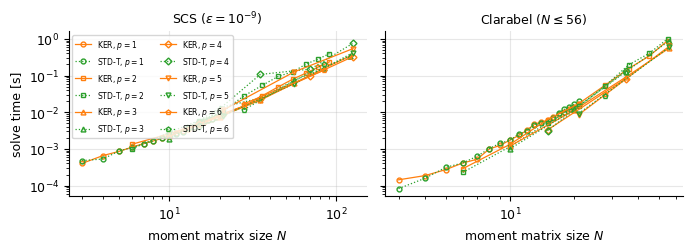

Total runtime 227.2 s


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for ax, solver in zip(axs, ['SCS', 'Clarabel']):
    for p, mk in zip(range(1, 7), 'os^Dvp'):
        for meth in ['KER', 'STD-T']:
            pts = [(x['N'], s['t']) for x in rows4 if x['p'] == p and x['meth'] == meth for s in x['res']
                   if s['solver'] == solver]
            if pts:
                ax.loglog(*zip(*pts), marker=mk, ls='-' if meth == 'KER' else ':', color=COL[meth], ms=3.5, lw=0.9,
                          mfc='none', label='%s, $p=%d$' % (meth, p) if solver == 'SCS' else None)
    ax.set_xlabel('moment matrix size $N$')
    ax.set_title('%s' % solver + (r' ($\varepsilon=10^{-9}$)' if solver == 'SCS' else r' ($N\leq56$)'), fontsize=9)
axs[0].set_ylabel('solve time [s]')
h, l = axs[0].get_legend_handles_labels()
axs[0].legend(h[:12], l[:12], fontsize=5.5, ncol=2, loc='upper left')
fig.tight_layout()
fig.savefig(os.path.join(FIGDIR, 'g2_scaling.pdf'))
plt.show()
print('Total runtime %.1f s' % (time.perf_counter() - T_START))

## Findings (stored outputs above)

1. **Polynomial $f$.** The kernel hierarchy brings no gain. K-exact coincides with STD at $n=m$ and matches it at every order on the camel (exact to the solver accuracy, flat at $t=2$ with rank 2, same atoms $\pm(0.08984,-0.71266)$); K-native carries the truncation bias ($0.12$, $7.7\cdot10^{-3}$, $3.3\cdot10^{-4}$, $1.0\cdot10^{-5}$, $2.6\cdot10^{-7}$ at $n=3,\dots,7$) and is flat at $t=2$ as well. On the Motzkin form, where no flat truncation exists, the $\theta$-weighted certificates give slightly tighter bounds at equal size ($n=4$: $-9.1\cdot10^{-5}$ and $-8.0\cdot10^{-5}$ against $-2.0\cdot10^{-4}$). SDP sizes and solve times are the same.
2. **$f=\omega^2q$.** At equal moment matrix size the kernel bound is a validated lower bound, and it is the most accurate validated bound on Q1 and Q2 (Q2, $N=91$: $9.6\cdot10^{-11}$, against $4.0\cdot10^{-8}$ for the Chebyshev fit and $1.0$ for the Taylor truncation). On Q3, whose minimiser lies on the boundary of $\mathcal X$, the Chebyshev fit is closer in raw value ($1.6\cdot10^{-6}$ against $9.5\cdot10^{-6}$ at $N=120$) but lies above $f^\star$, and after subtracting the fit error it is worse ($9.6\cdot10^{-5}$). Replacing $\theta_d$ by a Chebyshev fit of $\omega^{-2}$ does not help.
3. **Conditioning.** In the monomial basis the tilt changes $\kappa(M_d)$ by a factor between $0.98$ and $2.9$ (the sandwich allows $e^{pR^2}$), uniformly in $d$. The RKHS-orthonormal coordinates of the kernel are far worse conditioned ($2.7\cdot10^{50}$ against $1.2\cdot10^{22}$ at $d=30$, $R=1$), and the Chebyshev basis improves both ($39$ and $91$ at $d=30$, $R=1$). With SCS the monomial SDP of the kernel hierarchy stays accurate to about $10^{-9}$ up to $d=40$ ($p=1$) and $10^{-12}$ up to $n=14$ ($p=2$). What fails in monomials is the standard relaxation of a high-degree Chebyshev fit (Q1, $n\ge28$), whose monomial coefficients cancel; the same SDP in the Chebyshev basis is accurate. Clarabel ends with `AlmostSolved` ($10^{-7}$ to $10^{-5}$) on most instances, in both bases and for both hierarchies.
4. **Scaling.** The two hierarchies have the same cone structure and the same cost at a given $(p,n)$: SCS time grows like $N^{2.1}$ to $N^{2.2}$, Clarabel time like $N^{4}$ ($N\le56$), and the fitted exponents of KER and STD-T agree to within about $0.2$. What differs is the order needed: the level $d(\varepsilon)$ of Theorem 12 is $17$ at $R=2$, $\varepsilon=10^{-6}$ ($N=1140$ for $p=3$; $19$ from the bound $R^{2(d+1)}/(d+1)!$ of Lemma 11), while the measured errors on Q1 and Q2 reach $10^{-6}$ at $n\approx8$, because the truncation error matters only where $f<0$.

## 5. Numbers quoted in the paper

The comparison with the standard hierarchy in the subsection "A numerical illustration" (end of Section 5) and its
table quote the numbers printed below, computed from the runs of Sections 1 and 2 (monomial basis; for each program the
result of `best`, as in the figures). The table gives $f^\star$ minus the bound, so a positive entry is a lower bound on
$f^\star$ and a negative one is not. For the kernel relaxation (9b) the bound is $\lambda_d$ minus the residual
correction of Proposition 6: `ker_certified` re-solves the program with SCS and bounds on $\mathcal X$ the residual of the
numerical certificate (the $\ell^1$ norm of $c+A^\top z$, since $|u^\alpha|\le1$, plus the negative eigenvalues of the
dual blocks times their sizes); as $\lambda_d<0$ here, $f^\star\ge\lambda_d-\text{correction}$. For the standard relaxations
of the Chebyshev fit $f_C$ and of the Taylor fit $f_T$ the bound is the dual value, raw or minus the fit error
$\delta=\max|f-f_{\rm approx}|$ estimated on the points of `dense_pts` (an estimate, not a rigorous bound).

In [22]:
# numbers quoted in the paper (Section 5, "A numerical illustration")
def row_of(rows, name, n, meth):
    return next(x for x in rows if x['prob'] == name and x['n'] == n and x['meth'] == meth and x.get('basis', 'mono') == 'mono')

def tag(x):
    r = best(x['res'])
    return '%s:%s' % (r['solver'][:3], r['status'][:12])

print('Polynomial f (camel, f* = %.10f):' % POLY['camel']['fstar'])
for n in POLY['camel']['ns']:
    S_, E_, K_ = (row_of(rows1, 'camel', n, m) for m in ('STD', 'K-exact', 'K-native'))
    same = np.allclose(np.sort(E_['atoms'], 0), np.sort(S_['atoms'], 0), atol=1e-4)
    print('  n=%d N=%2d | STD - f* = %+.1e | K-exact - STD = %+.1e, same atoms: %s | K-native - f* = %+.1e | flat t: %s %s %s' % (
        n, S_['N'], S_['err'], E_['bound'] - S_['bound'], same, K_['err'], S_['tf'], E_['tf'], K_['tf']))

def ker_certified(name, n):
    # re-solve the kernel SDP (9b) with SCS and bound on X the residual of its numerical certificate:
    # for x = v(u)/theta(u) (feasible for every u in X), c.x = lam + <z, s> + (c + A'z).x with |u^alpha| <= 1 on X,
    # theta >= 1 and sup_X g_j = 1, so min_X q/theta >= lam - corr, and f* >= lam - corr when lam - corr < 0 (Prop. 6)
    P = NONPOLY[name]
    S = build(P['p'], n, P['q'], theta(P['p'], n, P['R'] ** 2), P['gs'], 'mono')
    perm = _scs_perm(S)
    sol = scs.SCS(dict(A=S['A'][perm, :].tocsc(), b=S['b'][perm], c=S['c']), dict(z=1, s=[N for _, N in S['blocks']]),
                  eps_abs=SCS_EPS, eps_rel=SCS_EPS, max_iters=SCS_MAXIT, verbose=False).solve()
    z = np.zeros(len(S['b'])); z[perm] = sol['y']
    corr = np.abs(S['c'] + S['A'].T @ z).sum() + sum(
        max(0.0, -np.linalg.eigvalsh(smat(z[a:a + N * (N + 1) // 2], N))[0]) * N for a, N in S['blocks'])
    return -z[0], corr, sol['info']['status']

CERT = {}
for name, P in NONPOLY.items():
    for n in P['ns']:
        CERT[name, n] = ker_certified(name, n)
dl = max(abs(CERT[k][0] - row_of(rows2, k[0], k[1], 'KER')['lam']) for k in CERT)
print('kernel certificates re-solved with SCS: %d programs, statuses %s, max |lambda - stored lambda| = %.1e, residual correction'
      ' at most %.1e' % (len(CERT), sorted({c[2] for c in CERT.values()}), dl, max(c[1] for c in CERT.values())))

print('\nf = omega^2 q, table (f* - bound; positive = lower bound on f*):')
print('%-3s %2s %4s | %9s %9s | %9s %9s | %9s | %s' % ('', 'p', 'N', 'kernel', 'corrected', 'Cheb raw', 'Cheb-delta', 'Tay-delta', 'solvers (KER, STD-C, STD-T)'))
for name, n in [('Q1', 12), ('Q2', 8), ('Q2', 12), ('Q3', 6), ('Q3', 7)]:
    K_, C_, T_ = (row_of(rows2, name, n, m) for m in ('KER', 'STD-C', 'STD-T'))
    assert K_['lam'] < 0 and K_['val'] == K_['lam']
    print('%-3s %2d %4d | %9.1e %9.1e | %9.1e %9.1e | %9.1e | %s' % (
        name, NONPOLY[name]['p'], K_['N'], -K_['verr'], NONPOLY[name]['fstar'] - (CERT[name, n][0] - CERT[name, n][1]),
        NONPOLY[name]['fstar'] - C_['lam'], -C_['verr'], -T_['verr'],
        ' '.join(tag(x) for x in (K_, C_, T_))))

cnt_best, cnt_all, lam_neg, other = 0, 0, True, []
for name, P in NONPOLY.items():
    for n in P['ns']:
        K_, C_, T_ = (row_of(rows2, name, n, m) for m in ('KER', 'STD-C', 'STD-T'))
        lam_neg &= K_['lam'] < 0
        gk = P['fstar'] - (CERT[name, n][0] - CERT[name, n][1])          # kernel bound with the residual correction
        gaps = [(g, m) for g, m in ((gk, 'KER'), (-C_['verr'], 'STD-C'), (-T_['verr'], 'STD-T')) if g >= 0]
        cnt_all += 1
        if gaps and min(gaps)[1] == 'KER':
            cnt_best += 1
        else:
            other.append('%s N=%d: ' % (name, K_['N']) + ', '.join('%s %.1e' % (m, g) for g, m in sorted(gaps)))
print('lambda_d < 0 in every KER run: %s; KER (with the residual correction) gives the smallest nonnegative f* - bound among KER, STD-C - delta, '
      'STD-T - delta in %d of %d (problem, n) pairs; the others: %s' % (lam_neg, cnt_best, cnt_all, other))

cla = [y for x in rows2 for y in x['res'] if y['solver'] == 'Clarabel']
scs = [y for x in rows2 for y in x['res'] if y['solver'] == 'SCS']
print('\nSection 2 statuses: Clarabel AlmostSolved in %d of %d runs, Solved in %d; SCS solved in %d of %d, the others: %s' % (
    sum(y['status'] == 'AlmostSolved' for y in cla), len(cla), sum(y['status'] == 'Solved' for y in cla),
    sum(y['status'] == 'solved' for y in scs), len(scs),
    sorted({(x['meth'], x['basis']) for x in rows2 for y in x['res'] if y['solver'] == 'SCS' and y['status'] != 'solved'})))
for meth in ('KER', 'STD-C'):
    e_s = [abs(z['esur']) for z in EXTR if z['meth'] == meth and z['basis'] == 'mono' and z['solver'] == 'SCS' and z['ok']]
    e_c = [abs(z['esur']) for z in EXTR if z['meth'] == meth and z['basis'] == 'mono' and z['solver'] == 'Clarabel'
           and z['status'] == 'AlmostSolved']
    print('  %-5s monomial basis, |value - own surrogate minimum|: SCS solved max %.1e (%d runs); Clarabel AlmostSolved %.1e to %.1e (%d runs)' % (
        meth, max(e_s), len(e_s), min(e_c), max(e_c), len(e_c)))


Polynomial f (camel, f* = -1.0316284535):
  n=3 N=10 | STD - f* = +1.6e-10 | K-exact - STD = +0.0e+00, same atoms: True | K-native - f* = +1.2e-01 | flat t: 2 2 2
  n=4 N=15 | STD - f* = +6.0e-12 | K-exact - STD = +6.1e-10, same atoms: True | K-native - f* = +7.7e-03 | flat t: 2 2 2
  n=5 N=21 | STD - f* = +9.6e-11 | K-exact - STD = -9.2e-11, same atoms: True | K-native - f* = +3.3e-04 | flat t: 2 2 2
  n=6 N=28 | STD - f* = +6.2e-11 | K-exact - STD = -6.0e-11, same atoms: True | K-native - f* = +1.0e-05 | flat t: 2 2 2
  n=7 N=36 | STD - f* = -1.4e-11 | K-exact - STD = +1.8e-10, same atoms: True | K-native - f* = +2.6e-07 | flat t: 2 2 2


kernel certificates re-solved with SCS: 39 programs, statuses ['solved'], max |lambda - stored lambda| = 0.0e+00, residual correction at most 1.2e-07

f = omega^2 q, table (f* - bound; positive = lower bound on f*):
     p    N |    kernel corrected |  Cheb raw Cheb-delta | Tay-delta | solvers (KER, STD-C, STD-T)
Q1   1   13 |   1.6e-10   1.7e-10 |  -9.5e-09   4.6e-09 |   3.1e-01 | SCS:solved SCS:solved SCS:solved
Q2   2   45 |   1.3e-06   1.3e-06 |  -6.5e-05   1.0e-04 |   2.8e+01 | SCS:solved SCS:solved SCS:solved
Q2   2   91 |   9.6e-11   1.9e-10 |   9.3e-09   4.0e-08 |   1.0e+00 | SCS:solved SCS:solved SCS:solved
Q3   3   84 |   7.7e-05   7.7e-05 |   1.0e-05   7.9e-04 |   3.5e-02 | SCS:solved SCS:solved SCS:solved
Q3   3  120 |   9.5e-06   9.5e-06 |  -1.5e-06   9.6e-05 |  -5.9e-05 | SCS:solved SCS:solved SCS:solved
lambda_d < 0 in every KER run: True; KER (with the residual correction) gives the smallest nonnegative f* - bound among KER, STD-C - delta, STD-T - delta in 35 of 39 (pro